## Figure 1. Study selection workflow and characteristics of the data included in NMWI construction. 


In [19]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")

In [2]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Coding_projects/NMWI


Systematic search and filtering: 37 Illumina-based 16S rRNA gene nasal microbiome studies (2967 samples) were identified, of which 27 studies (1654 samples) were retained after preprocessing and filtering. From these 27 studies and 1654 samples: 

In [3]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)

Found 27 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1654, and number of taxa: 184
Number of unique studies: 27

Sample_id per Category:
Category  n_sample_id
    case         1065
 control          589


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

### Figure 1.b
Geographic origins across four continents and 12 countries. 

In [4]:
merged_meta.groupby('Country')['BioProject.Number'].nunique().reset_index(name = 'bioprojects').sort_values('bioprojects', ascending = False)

,Country,bioprojects
2,China,6
11,USA,6
6,New Zealand,3
0,Austria,2
3,Germany,2
7,Poland,2
1,Belgium,1
4,Italy,1
5,Malaysia,1
8,Portugal,1


### Figure 1.c
Number of studies and their samples across seven disease phenotypes and a healthy reference group. Abbreviations: AR, allergic rhinitis; AS, asthma; CF, cystic fibrosis; CRS, chronic rhinosinusitis; CRS-AS, CRS with comorbid asthma; GPA, granulomatosis with polyangiitis; H, healthy; RA, rheumatoid arthritis.

In [5]:
fig1c = (
    merged_meta.groupby('Disease')
    .agg(
        n_bioprojects = ('BioProject.Number', 'nunique'),
        n_sample_id = ('Sample_id', 'nunique')
    )
    .sort_values('n_sample_id', ascending = False)
)
fig1c

,n_bioprojects,n_sample_id
Disease,,
CRS,11,652
Healthy,17,589
AR,4,137
Asthma,4,123
GPA,2,68
CRS + AS,2,34
CF,2,30
RA,2,21


### Figure 1.d
Mean relative taxonomic composition at the family and genus levels in healthy and non-healthy samples. 

---
Family-level. Most abundant families

Abundance of top 3: abundance    0.470192
dtype: float64


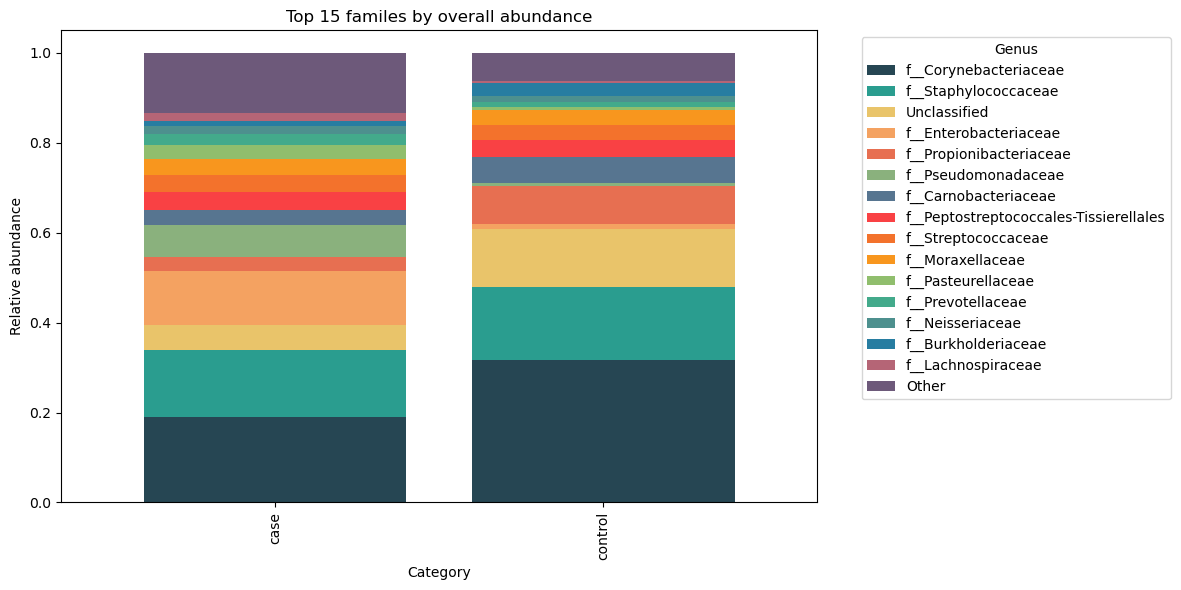

In [25]:
sample_to_category = merged_meta.set_index('Sample_id')['Category']
rel_abu = X.T.copy()
rel_abu = rel_abu.loc[:, rel_abu.columns.get_level_values(1).isin(sample_to_category.index)]
rel_abu = rel_abu.rename(columns=sample_to_category)
rel_abu_by_category = rel_abu.sum(axis=1).to_frame('abundance')
rel_abu_by_category['Family'] = [idx.split(';')[4] for idx in rel_abu_by_category.index]
rel_abu_by_category = rel_abu_by_category.groupby('Family').sum()
rel_abu_by_category = rel_abu_by_category.div(rel_abu_by_category.sum(axis=0), axis=1)
rel_abu_by_category.sort_values('abundance', ascending=False)
# rel_abu_by_category.sort_values('abundance', ascending=False).head(3).sum()
ans = rel_abu_by_category.loc[['f__Enterobacteriaceae', 'f__Staphylococcaceae', 'f__Corynebacteriaceae' ]].sum()
print(f'Abundance of top 3: {ans}' )


# Family plot abundance
top15 = (rel_abu_by_category.sort_values('abundance', ascending=False).head(15).index)

rel_abu_case_control = rel_abu.groupby(axis=1, level=1).sum()
rel_abu_case_control['Family'] = [idx.split(';')[4] for idx in rel_abu_case_control.index]
rel_abu_case_control = rel_abu_case_control.groupby('Family').sum()
rel_abu_case_control = rel_abu_case_control.div(rel_abu_case_control.sum(axis=0), axis=1)

# keep top 15, collapse the rest into "Other"
plot_df = rel_abu_case_control.copy()
plot_df['Family_plot'] = plot_df.index.where(plot_df.index.isin(top15), 'Other')
plot_df = plot_df.groupby('Family_plot').sum()
plot_df.sort_values('case', ascending = False)

# order bars by the overall ranking, with Other at the end
plot_order = list(top15) + ['Other']
plot_df = plot_df.reindex(plot_order, fill_value=0)
plot_df = plot_df.rename(index={"__": "Unclassified"})

palette = [
    "#264653", "#2A9D8F", "#E9C46A", "#F4A261",
    "#E76F51", "#8AB17D", "#577590", "#F94144",
    "#F3722C", "#F8961E", "#90BE6D", "#43AA8B",
    "#4D908E", "#277DA1", "#B56576", "#6D597A"
]

# stacked barplot
ax = plot_df.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    width=0.8, color = palette
)

ax.set_xlabel('Category')
ax.set_ylabel('Relative abundance')
ax.set_title('Top 15 familes by overall abundance')
ax.legend(title='Genus', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Figures/Fig1_f1.pdf')
plt.show()


---
Genus-level information

In [26]:
rel_abu = X.T.copy()
rel_abu = rel_abu.loc[:, rel_abu.columns.get_level_values(1).isin(sample_to_category.index)]
rel_abu = rel_abu.rename(columns=sample_to_category)
rel_abu_case_control = rel_abu.groupby(axis = 1, level = 1).sum()
rel_abu_case_control['Genus'] = [idx.split(';')[5] for idx in rel_abu_case_control.index]
rel_abu_case_control = rel_abu_case_control.groupby('Genus').sum()
rel_abu_case_control = rel_abu_case_control.div(rel_abu_case_control.sum(axis=0), axis=1)
print(rel_abu_case_control.loc[['g__Corynebacterium', 'g__Staphylococcus','g__Escherichia-Shigella', 'g__Cutibacterium']].sum(axis = 0))
rel_abu_overall = rel_abu.sum(axis=1).to_frame('abundance')
rel_abu_overall['Genus'] = [idx.split(';')[5] for idx in rel_abu_overall.index]
rel_abu_overall = rel_abu_overall.groupby('Genus').sum()
rel_abu_overall = rel_abu_overall.div(rel_abu_overall.sum(axis=0), axis=1)
print(rel_abu_overall.loc[['g__Corynebacterium', 'g__Staphylococcus','g__Escherichia-Shigella', 'g__Cutibacterium']].sum(axis = 0))
rel_abu_overall.sort_values('abundance', ascending=False)

Sample_id
case       0.462142
control    0.536903
dtype: float64
abundance    0.488765
dtype: float64


,abundance
Genus,
g__Corynebacterium,0.212401
g__Staphylococcus,0.154916
__,0.144961
g__Escherichia-Shigella,0.071698
g__Cutibacterium,0.049750
...,...
g__Devosia,0.000073
g__Exiguobacterium,0.000072
g__Psychrobacter,0.000066


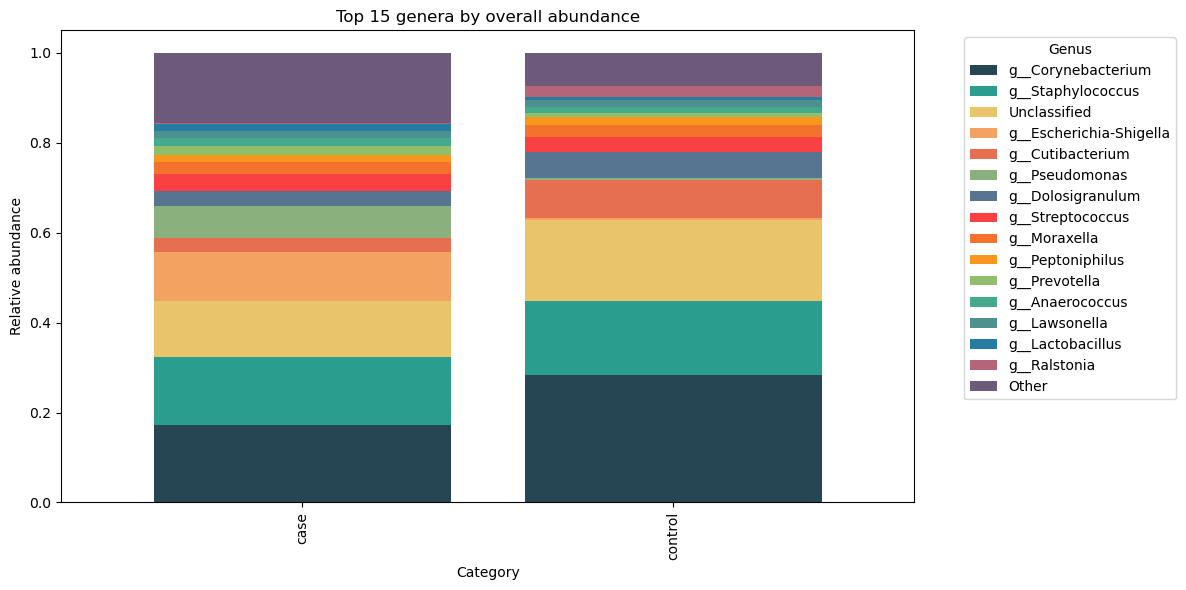

In [27]:
# top 15 genera based on overall abundance
top15 = (rel_abu_overall.sort_values('abundance', ascending=False).head(15).index)

# keep top 15, collapse the rest into "Other"
plot_df = rel_abu_case_control.copy()
plot_df['Genus_plot'] = plot_df.index.where(plot_df.index.isin(top15), 'Other')
plot_df = plot_df.groupby('Genus_plot').sum()

# order bars by the overall ranking, with Other at the end
plot_order = list(top15) + ['Other']
plot_df = plot_df.reindex(plot_order, fill_value=0)
plot_df = plot_df.rename(index={"__": "Unclassified"})


# stacked barplot
ax = plot_df.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    width=0.8,
    color = palette
)

ax.set_xlabel('Category')
ax.set_ylabel('Relative abundance')
ax.set_title('Top 15 genera by overall abundance')
ax.legend(title='Genus', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Figures/Fig1_f2.pdf')
plt.show()

In [ ]:
# Differential abundance use Diff_abundance_testing.R

### Fig 1.e-f
Distribution of genus prevalence across all samples. 

In [14]:
prevalence = (ra_sub_initial > 0).sum(axis=1) / ra_sub_initial.shape[1]
print(f'Initial shape: {ra_sub_initial.shape}') # taxa, samples
n_gt_05 = (prevalence > 0.5).sum()
print(f"Taxa with prevalence > 0.5: {n_gt_05}")
print(f"Taxa with prevalence < 0.01: {(prevalence <= 0.01).sum()}")
print(f"Taxa with prevalence < 0.5: {(prevalence < 0.5).sum()}")
print(f"Taxa with prevalence >= 0.05: {(prevalence >= 0.05).sum()}")


Initial shape: (2103, 1656)
Taxa with prevalence > 0.5: 8
Taxa with prevalence < 0.01: 1491
Taxa with prevalence < 0.5: 2095
Taxa with prevalence >= 0.05: 184


In [15]:
prev_cat = ra_sub_initial.loc[:, ra_sub_initial.columns.isin(sample_to_category.index)]
prev_cat= prev_cat.rename(columns=sample_to_category)
print((prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('case', ascending = False).head(8))

case_prev = (prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('case', ascending = False).head(8)
control_prev = (prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('control', ascending = False).head(8)
case_g = [idx.split(';')[5] for idx in case_prev.index]
control_g = [idx.split(';')[5] for idx in control_prev.index]
print(list(set(case_g)-set(control_g)))
print(list(set(control_g)-set(case_g)))
print(case_g); print(control_g)

                                                        case   control
OTU ID                                                                
d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphyl...  0.889202  0.891341
d__Bacteria;p__Actinobacteriota;c__Actinobacter...  0.856338  0.837012
d__Bacteria;p__Actinobacteriota;c__Actinobacter...  0.726761  0.694397
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactoba...  0.707981  0.578947
d__Bacteria;p__Firmicutes;c__Clostridia;o__Pept...  0.653521  0.597623
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...  0.614085  0.415959
d__Bacteria;p__Firmicutes;c__Clostridia;o__Pept...  0.584977  0.584041
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...  0.553991  0.477080
['g__Pseudomonas']
['g__Finegoldia']
['g__Staphylococcus', 'g__Corynebacterium', 'g__Cutibacterium', 'g__Streptococcus', 'g__Anaerococcus', 'g__Pseudomonas', 'g__Peptoniphilus', 'g__Acinetobacter']
['g__Staphylococcus', 'g__Corynebacterium', 'g__Cutibacterium', 'g__Anaerococcus', 'g__Pepto

In [16]:
(prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('case', ascending = False).head(8)

,case,control
OTU ID,,
d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphylococcales;f__Staphylococcaceae;g__Staphylococcus,0.889202,0.891341
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;f__Corynebacteriaceae;g__Corynebacterium,0.856338,0.837012
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium,0.726761,0.694397
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus,0.707981,0.578947
d__Bacteria;p__Firmicutes;c__Clostridia;o__Peptostreptococcales-Tissierellales;f__Peptostreptococcales-Tissierellales;g__Anaerococcus,0.653521,0.597623
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pseudomonadales;f__Pseudomonadaceae;g__Pseudomonas,0.614085,0.415959
d__Bacteria;p__Firmicutes;c__Clostridia;o__Peptostreptococcales-Tissierellales;f__Peptostreptococcales-Tissierellales;g__Peptoniphilus,0.584977,0.584041
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pseudomonadales;f__Moraxellaceae;g__Acinetobacter,0.553991,0.477080


In [17]:
(prev_cat>0).mean(axis =1).to_frame('abundance').sort_values('abundance', ascending = False).head(8)

,abundance
OTU ID,
d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphylococcales;f__Staphylococcaceae;g__Staphylococcus,0.889964
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Corynebacteriales;f__Corynebacteriaceae;g__Corynebacterium,0.849456
d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium,0.715236
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus,0.662031
d__Bacteria;p__Firmicutes;c__Clostridia;o__Peptostreptococcales-Tissierellales;f__Peptostreptococcales-Tissierellales;g__Anaerococcus,0.633615
d__Bacteria;p__Firmicutes;c__Clostridia;o__Peptostreptococcales-Tissierellales;f__Peptostreptococcales-Tissierellales;g__Peptoniphilus,0.584643
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pseudomonadales;f__Pseudomonadaceae;g__Pseudomonas,0.543531
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pseudomonadales;f__Moraxellaceae;g__Acinetobacter,0.526602


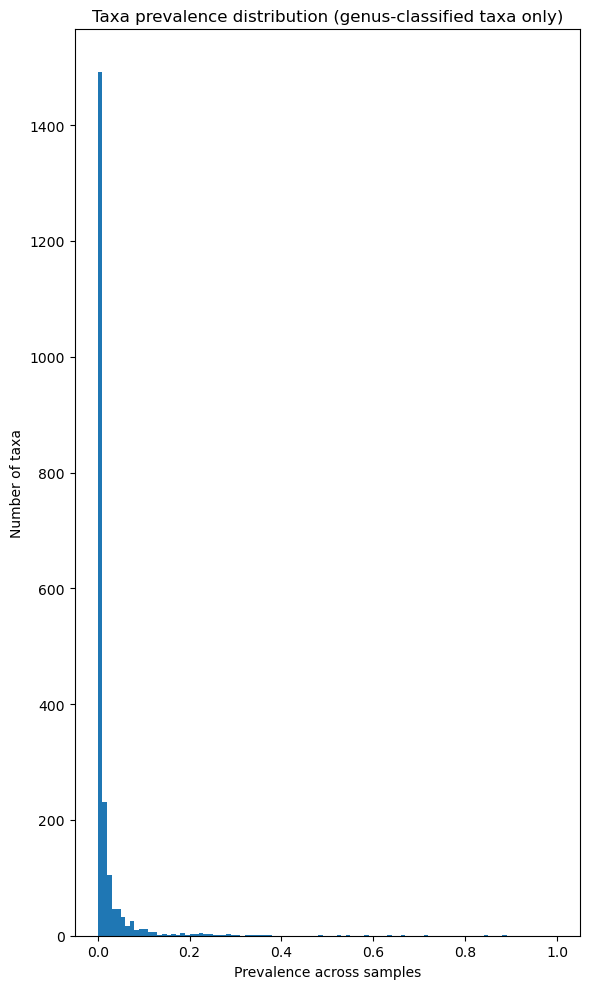

In [18]:
bins = np.linspace(0, 1, 101)  # 0, 0.05, ..., 1.0
counts, edges = np.histogram(prevalence, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(6, 10))
plt.bar(centers, counts, width=np.diff(edges), align='center')

plt.xlabel("Prevalence across samples")
plt.ylabel("Number of taxa")
# plt.ylim(0, 200)

plt.title("Taxa prevalence distribution (genus-classified taxa only)")
plt.tight_layout()
plt.show()

### Figure 1.g
PCoA of Bray–Curtis dissimilarity (PERMANOVA, R2 = 0.024, P < 0.001), with the same ordination colored by health status (left) and disease phenotype (right). 

In [ ]:
#run Codes/Auxiliary_files/PCOA_analysis.R